# Module 5 1st Homework — NOAA Buoy (Station 44013)  
**Linear models + regularization + classification + evaluation (A–C)**

In this notebook you’ll apply Module 5 Sections **A–C** to the NOAA buoy dataset (station **44013**):

- **A (Linear models):** OLS baseline regression + coefficient interpretation  
- **A (Regularization):** Ridge + Lasso, tune α on validation  
- **B (Classification):** Logistic regression + (optional) kNN baseline  
- **C (Evaluation):** RMSE/MAE + tail diagnostics, confusion matrix, ROC vs PR, calibration, cost-based thresholds, precision@k

> We are using **random splits** (not temporal splits) for this project notebook so the evaluation mirrors the NYC 311 approach and avoids time-window artifacts during instruction.  
> (In real forecasting you would typically use time-based splits — we’ll discuss that later.)

---

## Deliverable
At the end, write a short **evaluation memo**.



In [13]:
# === Setup ===



## 1) Load curated NOAA data (Module 2 homework artifact)

This project uses the parquet file produced in Module 2 NOAA homework:

- `~/work/homework_2_noaa/data/warehouse/ndbc_curated_44013.parquet`

Expected columns:
`station_id, time_utc, obs_day, obs_hour, dayofweek, is_weekend, wind_high, temp_gap_c, WSPD, GST, WVHT, DPD, APD, PRES, ATMP, WTMP, WDIR`


Looking for: /home/jupyter-kerblesl@isu.edu/work/homework_2_noaa/data/warehouse/ndbc_curated_44013.parquet
Exists? True
Loaded: m2_hw_noaa_curated_44013
Shape: (6470, 18)


,station_id,time_utc,obs_day,obs_hour,dayofweek,is_weekend,wind_high,temp_gap_c,WSPD,GST,WVHT,DPD,APD,PRES,ATMP,WTMP,WDIR,_source
0,44013,2026-01-25 05:40:00+00:00,2026-01-25,5,6,1,0,-15.3,9.0,12.0,NaN,NaN,NaN,1037.3,-10.4,4.9,330.0,m2_hw_noaa_curated_44013
1,44013,2026-01-25 05:30:00+00:00,2026-01-25,5,6,1,0,-15.3,10.0,12.0,NaN,NaN,NaN,1037.3,-10.4,4.9,330.0,m2_hw_noaa_curated_44013
2,44013,2026-01-25 05:20:00+00:00,2026-01-25,5,6,1,0,-15.1,9.0,12.0,1.2,5.0,3.8,1037.2,-10.2,4.9,330.0,m2_hw_noaa_curated_44013
3,44013,2026-01-25 05:10:00+00:00,2026-01-25,5,6,1,0,-15.0,9.0,12.0,NaN,NaN,NaN,1037.4,-10.1,4.9,330.0,m2_hw_noaa_curated_44013
4,44013,2026-01-25 05:00:00+00:00,2026-01-25,5,6,1,0,-15.0,9.0,12.0,NaN,NaN,NaN,1037.4,-10.2,4.8,320.0,m2_hw_noaa_curated_44013


In [15]:
# Quick schema + missingness snapshot



station_id                 object
time_utc      datetime64[ns, UTC]
obs_day                    object
obs_hour                    int32
dayofweek                   int32
is_weekend                  int64
wind_high                   int64
temp_gap_c                float64
WSPD                      float64
GST                       float64
WVHT                      float64
DPD                       float64
APD                       float64
PRES                      float64
ATMP                      float64
WTMP                      float64
WDIR                      float64
_source                    object
dtype: object


,% missing
DPD,67.22
WVHT,59.80
APD,59.80
temp_gap_c,1.30
WTMP,1.21
WDIR,0.34
ATMP,0.15
WSPD,0.09
GST,0.09
PRES,0.05


time_utc min: 2025-12-11 00:00:00+00:00
time_utc max: 2026-01-25 05:40:00+00:00


## 2) Preprocessing helper

We will build a preprocessing pipeline that:
- imputes missing numeric values (median)
- imputes missing categoricals (most frequent)
- standardizes numerics
- one-hot encodes categoricals
- drops datetimes (unless explicitly engineered upstream)

This prevents “mystery NaNs” in sklearn pipelines.


# Part A — Regression (Linear models + regularization)

We will predict a continuous target from weather/ocean variables.

### Regression target (recommended): `WVHT`
`WVHT` = significant wave height (meters).  
We’ll predict it from wind, pressure, temperature, and time-derived features.


Regression rows: 2601
Regression feature count: 13


,obs_hour,dayofweek,is_weekend,wind_high,temp_gap_c,WSPD,GST,DPD,APD,PRES,ATMP,WTMP,WDIR
2,5,6,1,0,-15.1,9.0,12.0,5.0,3.8,1037.2,-10.2,4.9,330.0
5,4,6,1,0,-15.0,10.0,12.0,4.0,3.8,1037.6,-10.1,4.9,320.0
8,4,6,1,0,-14.9,10.0,13.0,4.0,3.8,1037.6,-10.0,4.9,320.0


In [18]:
# Random split for regression



Split sizes: 1820 390 391
Target summary (train):


count    1820.000000
mean        0.972363
std         0.510430
min         0.200000
25%         0.600000
50%         0.900000
75%         1.200000
max         3.200000
dtype: float64

In [19]:
# Preprocess + metric helpers



Regression columns: 13 numeric | 0 categorical | 0 datetime dropped


## A.1 OLS baseline + interpretation

We start with OLS as a baseline:
- fit OLS
- evaluate on validation and test
- extract coefficients (direction + relative importance)

> Interpretation note: With one-hot encoding + scaling, coefficients are comparable in magnitude, but correlated features can still “share credit.”


In [ ]:
# Evaluate on validation and test


In [21]:
# Coefficient extraction (post-preprocessing)



,feature,coef,abs_coef
8,APD,0.325203,0.325203
5,WSPD,0.195675,0.195675
6,GST,0.122244,0.122244
12,WDIR,0.045356,0.045356
3,wind_high,-0.044358,0.044358
9,PRES,-0.033176,0.033176
4,temp_gap_c,-0.021901,0.021901
1,dayofweek,-0.018968,0.018968
11,WTMP,0.015355,0.015355
7,DPD,-0.010850,0.010850


## A.2 Ridge + Lasso (tune α on validation)

We tune α on validation (simple grid).  
Then evaluate best model on test.

Why regularize?
- Ridge stabilizes coefficients under collinearity
- Lasso can produce sparse models (feature selection)


,label,MAE,RMSE,R2,MedianAbsErr,P90AbsErr,P95AbsErr,alpha,family
3,ridge_alpha_10.0_val,0.167127,0.244904,0.791121,0.113433,0.357926,0.492873,10.0000,ridge/ols
6,lasso_alpha_0.0005_val,0.167002,0.244943,0.791054,0.114171,0.356475,0.490920,0.0005,lasso
2,ridge_alpha_1.0_val,0.167216,0.244946,0.791050,0.113758,0.357025,0.491972,1.0000,ridge/ols
1,ridge_alpha_0.1_val,0.167226,0.244952,0.791038,0.113957,0.356883,0.491857,0.1000,ridge/ols
0,ols_alpha_0.0_val,0.167227,0.244953,0.791037,0.113979,0.356868,0.491844,0.0000,ridge/ols
7,lasso_alpha_0.001_val,0.166797,0.244963,0.791020,0.114287,0.355899,0.488263,0.0010,lasso
4,ridge_alpha_50.0_val,0.167302,0.245104,0.790780,0.113924,0.348201,0.493095,50.0000,ridge/ols
8,lasso_alpha_0.005_val,0.166159,0.245843,0.789516,0.118805,0.353734,0.467002,0.0050,lasso
9,lasso_alpha_0.01_val,0.166744,0.248293,0.785300,0.111661,0.354499,0.462217,0.0100,lasso
5,ridge_alpha_200.0_val,0.170118,0.248823,0.784383,0.114642,0.359616,0.484916,200.0000,ridge/ols


Best on validation: ridge_alpha_10.0_val | alpha: 10.0 | RMSE: 0.2449040539418305


,label,MAE,RMSE,R2,MedianAbsErr,P90AbsErr,P95AbsErr
0,ols_test,0.152646,0.217123,0.817806,0.109992,0.306654,0.446774
1,ridge_alpha_10.0_test,0.152208,0.217144,0.817772,0.109258,0.302599,0.446011


## A.3 Regression diagnostics: residuals + tail risk

We go beyond a single metric:
- residual histogram
- absolute error histogram
- residuals vs predicted (pattern detection)


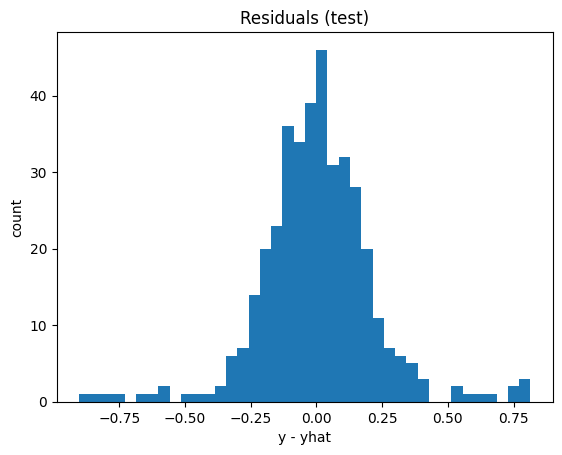

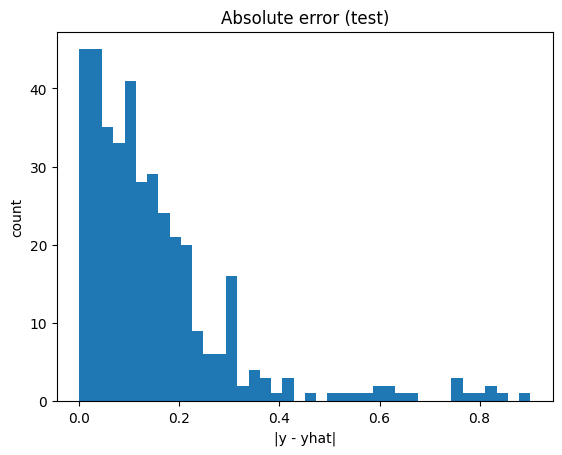

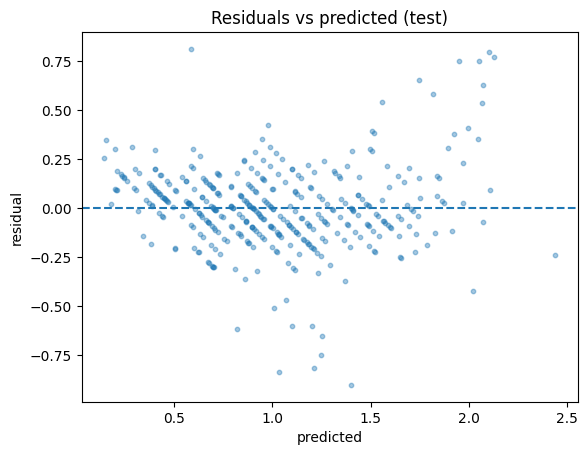

Median abs error: 0.10925789836097033
P90 abs error   : 0.3025993179840134
P95 abs error   : 0.4460114989753733


## A.4 Slice evaluation (regression)

Even with one buoy, performance can vary by:
- hour of day (`obs_hour`)
- weekend vs weekday (`is_weekend`)


/tmp/ipykernel_693709/3632017117.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_hour = df_test_reg.groupby("obs_hour").apply(group_reg_metrics).sort_values("RMSE", ascending=False)
/tmp/ipykernel_693709/3632017117.py:16: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  by_weekend = df_test_reg.groupby("is_weekend").apply(group_reg_metrics).sort_values("RMSE", ascending=False)


,n,MAE,RMSE,P90AbsErr
obs_hour,,,,
20,18.0,0.220189,0.333698,0.689243
17,17.0,0.218878,0.295772,0.476440
8,18.0,0.176150,0.293643,0.520672
12,21.0,0.179260,0.254126,0.288282
14,18.0,0.161317,0.253751,0.337548
7,17.0,0.187686,0.252497,0.467669
11,17.0,0.154660,0.240484,0.272875
21,16.0,0.140127,0.231022,0.366043
6,17.0,0.157362,0.226010,0.353202


,n,MAE,RMSE,P90AbsErr
is_weekend,,,,
0,277.0,0.151880,0.220766,0.306322
1,114.0,0.153003,0.208079,0.297346


# Part B — Classification baselines (Logistic regression + optional kNN)

### Classification target: `wind_high`

We will fit logistic regression on a **SAFE** feature set (to avoid trivial leakage).
Then we’ll evaluate:
- threshold sweep
- ROC vs PR curves
- calibration
- precision@k / lift@k


Rows: 6470
Positive rate: 0.16367851622874807


,obs_hour,dayofweek,is_weekend,temp_gap_c,WVHT,DPD,APD,PRES,ATMP,WTMP,WDIR
0,5,6,1,-15.3,NaN,NaN,NaN,1037.3,-10.4,4.9,330.0
1,5,6,1,-15.3,NaN,NaN,NaN,1037.3,-10.4,4.9,330.0
2,5,6,1,-15.1,1.2,5.0,3.8,1037.2,-10.2,4.9,330.0


Split sizes: 4528 971 971
Pos rates  : 0.16364840989399293 0.16374871266735325 0.16374871266735325


## B.1 Threshold sweep (validation)

,label,threshold,accuracy,precision,recall,f1,roc_auc,avg_precision,log_loss,brier
29,,0.775,0.905252,0.731034,0.666667,0.697368,0.909665,0.709785,0.385903,0.123778
31,,0.825,0.908342,0.796610,0.591195,0.678700,0.909665,0.709785,0.385903,0.123778
30,,0.800,0.903193,0.744361,0.622642,0.678082,0.909665,0.709785,0.385903,0.123778
28,,0.750,0.894954,0.681529,0.672956,0.677215,0.909665,0.709785,0.385903,0.123778
32,,0.850,0.906282,0.809091,0.559748,0.661710,0.909665,0.709785,0.385903,0.123778
26,,0.700,0.879506,0.616667,0.698113,0.654867,0.909665,0.709785,0.385903,0.123778
27,,0.725,0.881565,0.626437,0.685535,0.654655,0.909665,0.709785,0.385903,0.123778
25,,0.675,0.867147,0.577320,0.704403,0.634561,0.909665,0.709785,0.385903,0.123778
22,,0.600,0.853759,0.537118,0.773585,0.634021,0.909665,0.709785,0.385903,0.123778
21,,0.575,0.849640,0.527426,0.786164,0.631313,0.909665,0.709785,0.385903,0.123778


Best-F1 threshold: 0.775


## B.2 ROC vs PR curves (test)

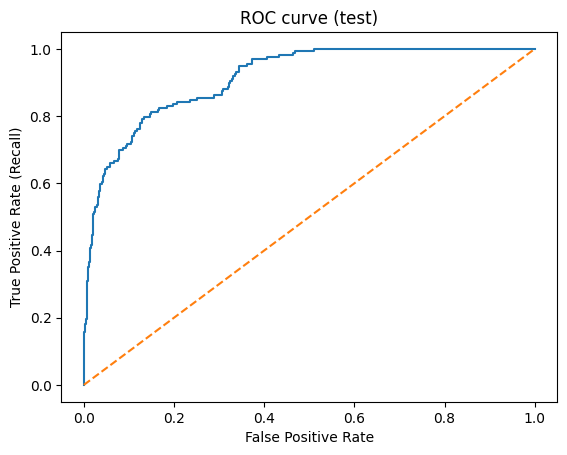

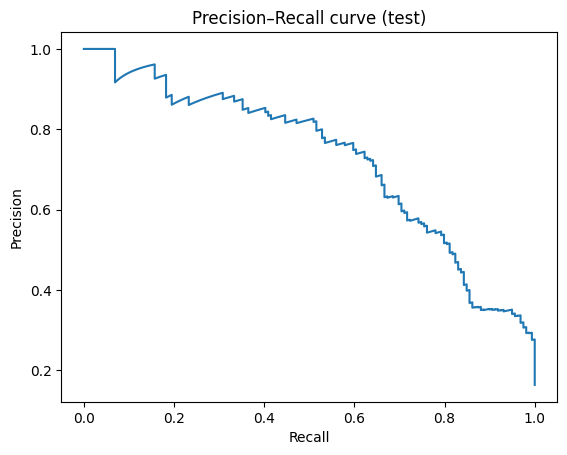

ROC-AUC: 0.9132819035226323
PR-AUC (avg precision): 0.7265993680145998


## B.3 Calibration (test)

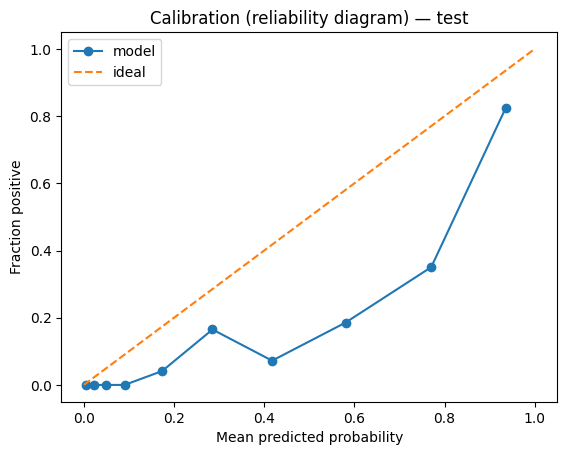

Brier score: 0.12560444159991369
Log loss   : 0.3836576785873874


## B.4 Precision@k / Lift@k (ranking evaluation)

,k,base_rate,positives_total,positives_in_topk,precision_at_k,recall_at_k,lift_at_k
0,25,0.163749,159,24,0.960,0.150943,5.862642
1,50,0.163749,159,44,0.880,0.276730,5.374088
2,100,0.163749,159,82,0.820,0.515723,5.007673
3,200,0.163749,159,115,0.575,0.723270,3.511478
4,500,0.163749,159,155,0.310,0.974843,1.893145


## B.5 kNN baseline (SVD + kNN)

LogReg PR-AUC: 0.7265993680145998
kNN   PR-AUC: 0.9620910475420117


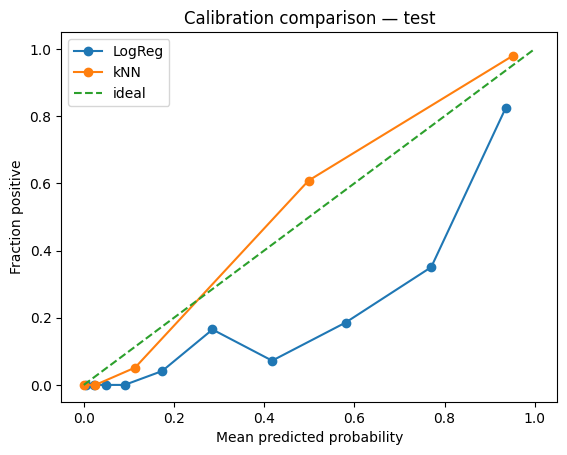

# Deliverable: Evaluation memo

Write **12–16 bullets** with real values from your outputs.

## Regression
1) Target (WVHT) and why it matters  
2) Your split protocol (random)  
3) OLS vs best regularized model (MAE/RMSE/R²)  
4) Tail risk: report P90 or P95 absolute error  
5) Residual diagnosis: any pattern? any heteroskedasticity?  
6) Slice with worst RMSE (hour or weekend) and possible explanation  
7) 1–2 feature interpretations from coefficients (direction + why plausible)

## Classification
8) Target (`wind_high`) and base rate  
9) Threshold policy used (best-F1) and why  
10) ROC-AUC vs PR-AUC — what does this say under imbalance?  
11) Calibration: do probabilities mean what they say?  
12) precision@k: if you can only review k=100 cases, what precision/lift do you get?  
13) One improvement you’d try next (feature engineering, label definition, monitoring)

